## Importy


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp
import warnings

##Exe 11.1

In [2]:
L = 2.0
T = 1.0
D = 0.1

Nx = 50
Nt = 1000

dx = L / Nx
dt = T / Nt

r = D * dt / dx**2
print("r =", r)

x = np.linspace(0, L, Nx+1)
t = np.linspace(0, T, Nt+1)
u = np.zeros((Nx+1, Nt+1))

for i in range(Nx+1):
    u[i, 0] = np.cos(np.pi * x[i])

for j in range(Nt+1):
    u[0, j] = 0
    u[Nx, j] = 0.2 * np.cos(5 * t[j])

for j in range(Nt):
    for i in range(1, Nx):
        u[i, j+1] = (
            r * u[i-1, j]
            + (1 - 2*r) * u[i, j]
            + r * u[i+1, j]
        )

r = 0.0625


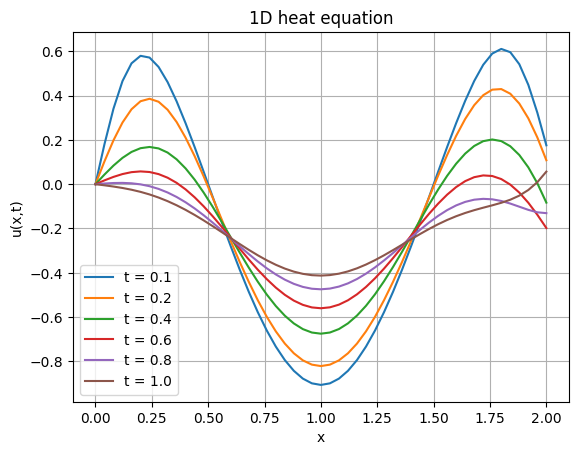

In [3]:
times = [100, 200, 400, 600, 800, 1000]

for j in times:
    plt.plot(x, u[:, j], label=f"t = {t[j]:.1f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("1D heat equation")
plt.legend()
plt.grid()
plt.show()

## Exe 11.2

In [4]:
L = 1.0
T = 1.0
c = 1.0

Nx = 100
Nt = 1000

dx = L / Nx
dt = T / Nt

r = (c * dt / dx)**2
if r >= 1:
  raise ValueError(f"r >= 1, r={r})")

x = np.linspace(0, L, Nx+1)
t = np.linspace(0, T, Nt+1)
u = np.zeros((Nx+1, Nt+1))

x0 = 0.4 * L

for i in range(Nx+1):
    if x[i] < x0:
        u[i, 0] = x[i] / x0
    else:
        u[i, 0] = (L - x[i]) / (L - x0)

u[0, 0] = 0
u[Nx, 0] = 0

for j in range(Nt+1):
    u[0, j] = 0
    u[Nx, j] = 0

for i in range(1, Nx):
    u[i, 1] = u[i, 0] + (r/2) * (u[i-1, 0] - 2*u[i, 0] + u[i+1, 0])

for j in range(1, Nt):
    for i in range(1, Nx):
        u[i, j+1] = (
            -u[i, j-1]
            + 2*u[i, j]
            + r * (u[i-1, j] - 2*u[i, j] + u[i+1, j]))

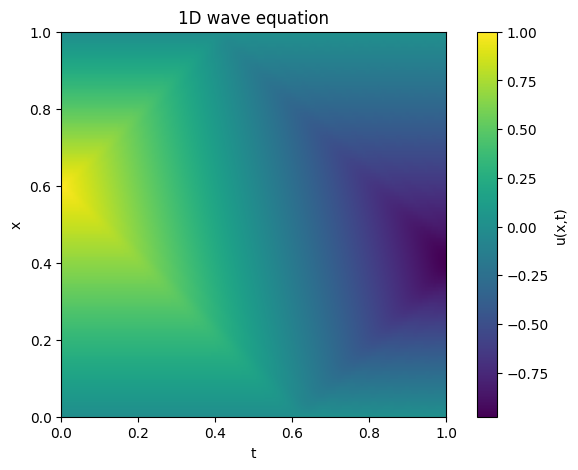

In [5]:
plt.figure(figsize=(8,5))
plt.imshow(u, extent=[0, T, 0, L], cmap='viridis')

plt.colorbar(label='u(x,t)')
plt.xlabel('t')
plt.ylabel('x')
plt.title('1D wave equation')

plt.show()